In [1]:
# importing the file

In [2]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
import matplotlib.pyplot as plt

In [3]:
image = '../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits'
file = fits.open(image)

In [4]:
# image structure

In [5]:
file.info()

Filename: ../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     375   ()      
  1  SCI_BKSUB     1 ImageHDU        75   (11500, 6500)   float64   
  2  SCI           1 ImageHDU        75   (11500, 6500)   float32   
  3  ERR           1 ImageHDU        10   (11500, 6500)   float32   
  4  CON           1 ImageHDU        10   (11500, 6500, 1)   int32   
  5  WHT           1 ImageHDU         9   (11500, 6500)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (11500, 6500)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (11500, 6500)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (11500, 6500)   float32   
  9  BKGD          1 ImageHDU        39   (11500, 6500)   float64   
 10  BKGMASK       1 ImageHDU        41   (11500, 6500)   uint8 (rescales to int8)   
 11  HDRTAB        1 BinTableHDU    820   6R x 405C   [23A, 5A, 3A, 51A, 7A, 13A, 3A, 5A, 7A, 10A, 4A, L, 

In [6]:
sci = file["SCI"].data
err = file["ERR"].data
sci_bkgsub = file["SCI_BKSUB"].data
wht = file["WHT"].data
nodata = (wht <= 0) | (sci == 0) | ~np.isfinite(sci)
print(nodata.mean())

0.5013612173913043


In [7]:
sci

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6500, 11500), dtype='>f4')

In [8]:
err

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(6500, 11500), dtype='>f4')

In [9]:
# finding the global sky threshold and noise spread

In [10]:
h, w = sci.shape
tile = 200
n_rows, n_cols = h // tile, w // tile
medians = np.full((n_rows, n_cols), np.nan)
spreads = np.full((n_rows, n_cols), np.nan)

for i in range(n_rows):
    for j in range(n_cols):
        box      = sci[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        box_mask = nodata[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        real = box[~box_mask]
        if real.size < 0.5 * box.size:
            continue
        mean, med, stddev = sigma_clipped_stats(real)
        medians[i, j] = med
        spreads[i, j] = stddev

In [11]:
sky   = np.nanmedian(medians)
noise = np.nanmedian(spreads)
rms   = np.sqrt(np.nanmedian(spreads**2))
n = 5
threshold = sky + n * noise
suspects = (sci > threshold) & ~nodata
print(suspects.mean())

0.012324334448160536


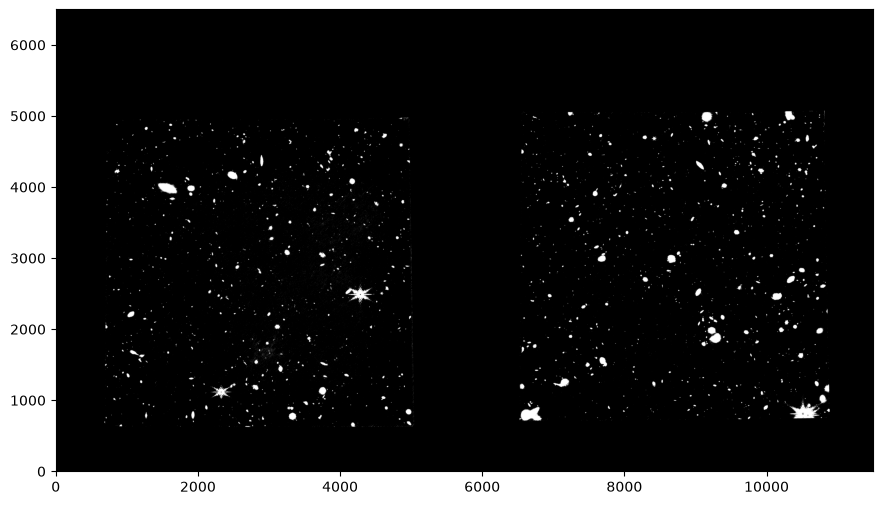

In [12]:
plt.figure(figsize=(12, 6))
plt.imshow(suspects, origin="lower", cmap="grey")
plt.show()

In [13]:
# source detection & labeling on a 2000px * 2000px testing tile

In [14]:
# Use the entire mosaic rather than a 2000 x 2000 testing tile.
y0, y1 = 0, sci.shape[0]
x0, x1 = 0, sci.shape[1]

cut = sci[y0:y1, x0:x1].astype(np.float64)
cut_mask = nodata[y0:y1, x0:x1]

print(f"Processing full mosaic: {cut.shape[1]} x {cut.shape[0]} pixels")
print(f"Invalid-pixel fraction: {cut_mask.mean():.4f}")

Processing full mosaic: 11500 x 6500 pixels
Invalid-pixel fraction: 0.5014


In [15]:
from photutils.segmentation import detect_sources

cut_sub = cut - sky
cut_sub[~np.isfinite(cut_sub)] = 0.0

segm = detect_sources(cut_sub, threshold=n * noise, n_pixels=5, mask=cut_mask)
if segm is None:
    print("No sources detected")
else:
    print(segm.n_labels)

4043


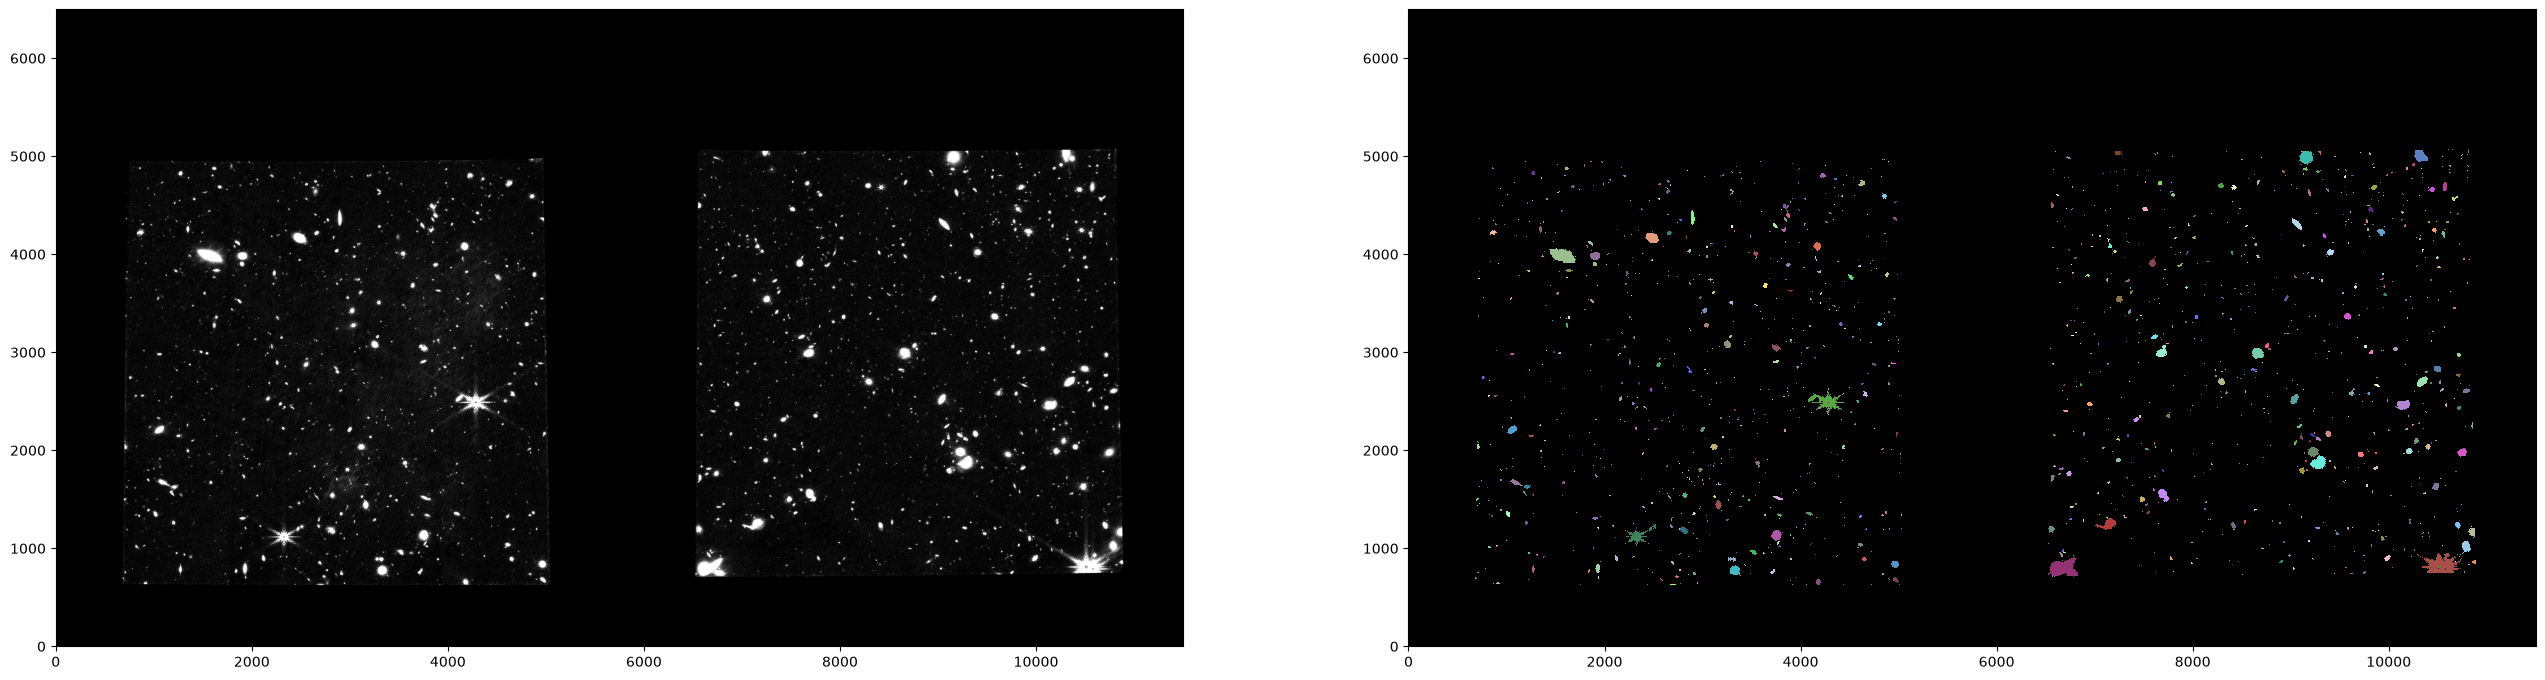

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm.data, origin="lower", cmap=segm.cmap, interpolation="nearest")
plt.show()

In [17]:
# instead of a single global threshold, we can divide the tile in hundred sub-tiles and define their sky threshold separately

In [18]:
from scipy.ndimage import zoom

# Replace empty sky tiles with the global estimates before interpolation.
medians_filled = np.where(np.isfinite(medians), medians, sky)
spreads_filled = np.where(np.isfinite(spreads), spreads, rms)

# Interpolate the tile-level background and noise maps to the full mosaic size.
zoom_factors = (
    cut.shape[0] / medians_filled.shape[0],
    cut.shape[1] / medians_filled.shape[1],
)

sky_cut = zoom(medians_filled, zoom_factors, order=1, mode="nearest")
rms_cut = zoom(spreads_filled, zoom_factors, order=1, mode="nearest")

# Ensure the interpolated arrays exactly match the mosaic dimensions.
sky_cut = sky_cut[:cut.shape[0], :cut.shape[1]]
rms_cut = rms_cut[:cut.shape[0], :cut.shape[1]]

if sky_cut.shape != cut.shape or rms_cut.shape != cut.shape:
    raise ValueError(
        f"Background-map shape mismatch: image={cut.shape}, "
        f"sky={sky_cut.shape}, noise={rms_cut.shape}"
    )

cut_sub = cut - sky_cut
cut_sub[~np.isfinite(cut_sub)] = 0.0

print(f"Full-mosaic background maps created: {sky_cut.shape}")

Full-mosaic background maps created: (6500, 11500)


In [19]:
segm_local = detect_sources(cut_sub, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_local.n_labels)

2938


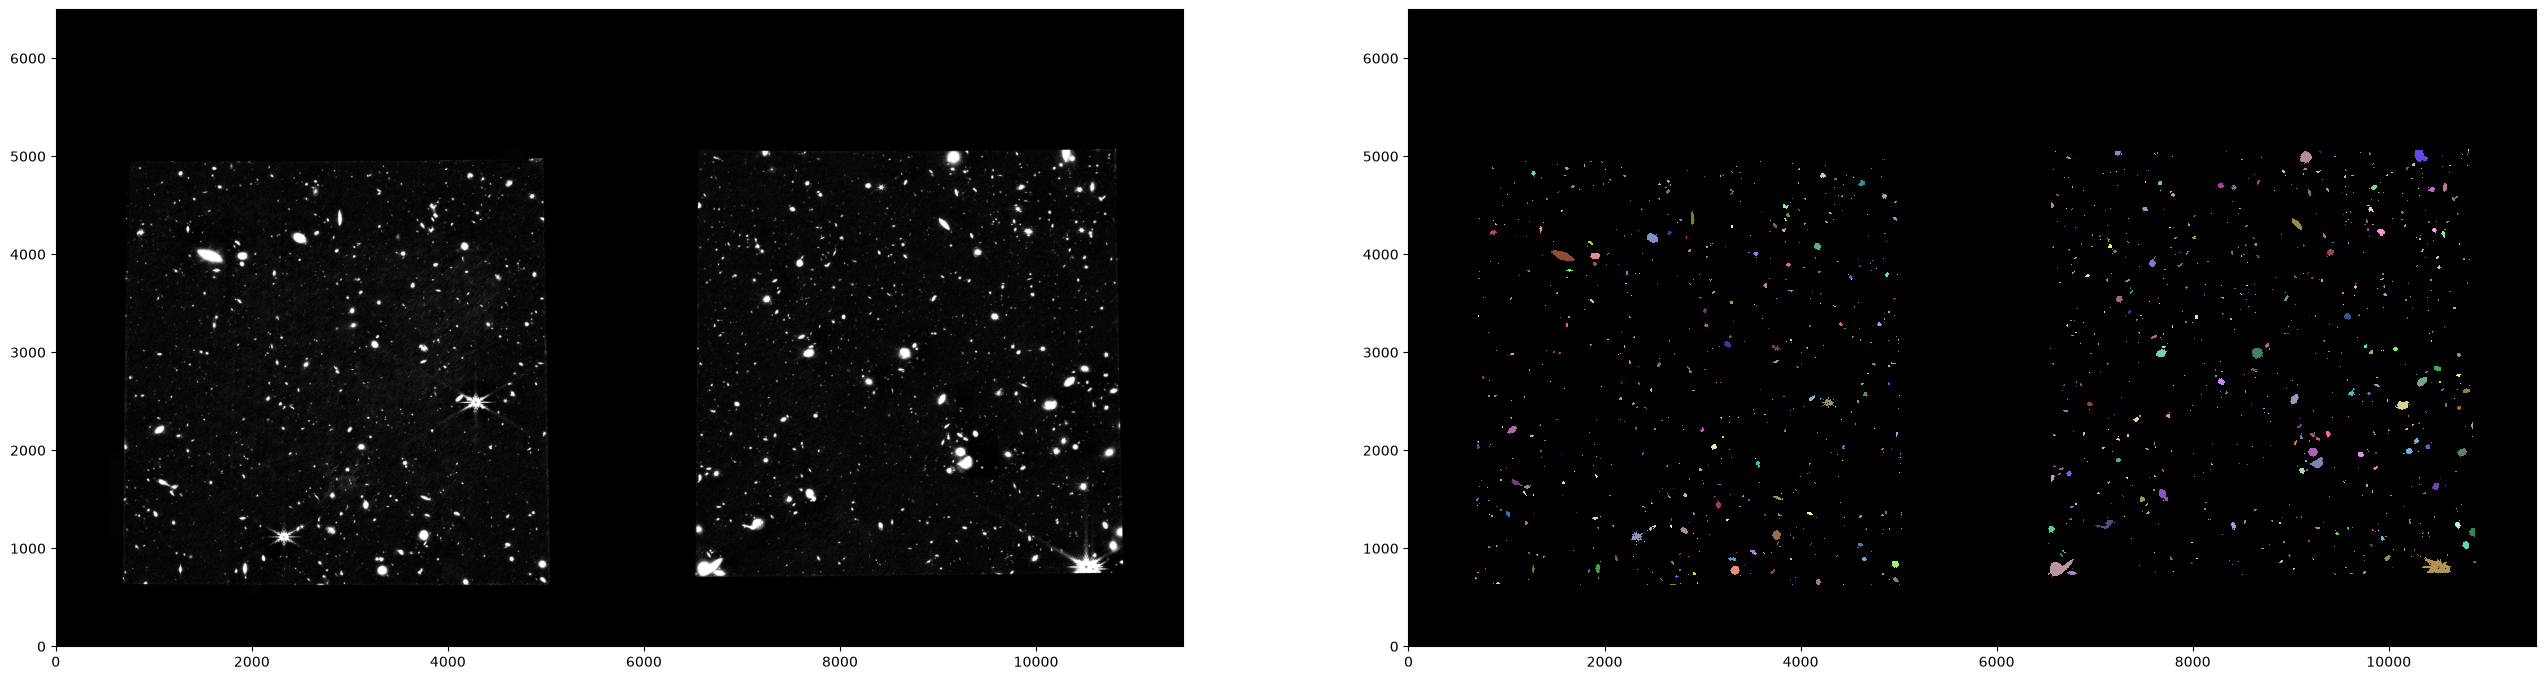

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
plt.show()

In [21]:
# convolving to not lose the edge pixels of the source and avoid them counted as a different source. 

In [22]:
# consequently this step will cause a drop in count of the detected sources. 

In [23]:
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel

kernel = make_2dgaussian_kernel(5.0, size=11)
conv = convolve(cut_sub, kernel, mask=cut_mask)
segm_conv = detect_sources(conv, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_conv.n_labels)

1512


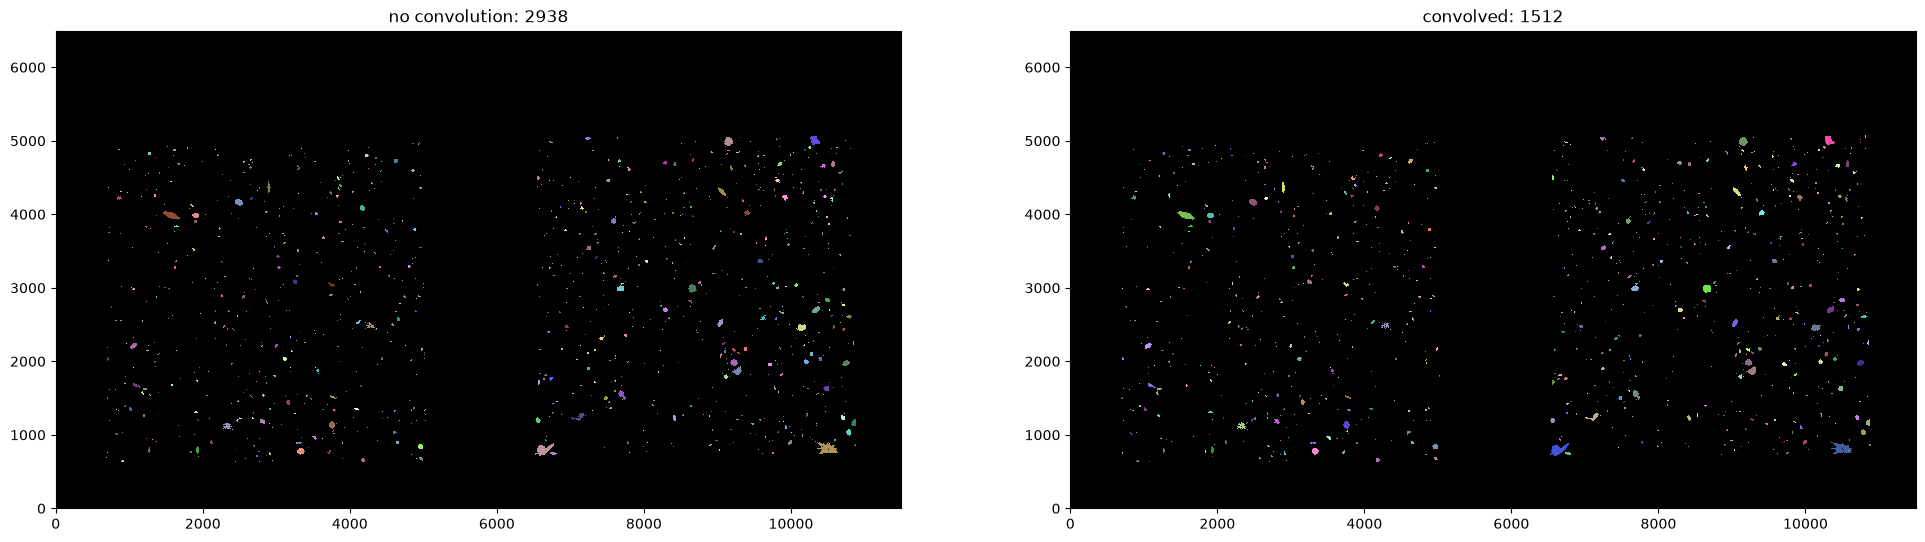

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
ax[0].set_title(f"no convolution: {segm_local.n_labels}")
ax[1].imshow(segm_conv.data, origin="lower", cmap=segm_conv.cmap, interpolation="nearest")
ax[1].set_title(f"convolved: {segm_conv.n_labels}")
plt.show()

In [25]:
# let's assign each detected source a unique, global coorindation using the WCS method. 

In [26]:
from astropy.wcs import WCS
wcs_full = WCS(file["SCI"].header)
wcs_cut  = wcs_full[y0:y1, x0:x1]

Set DATE-AVG to '2022-12-21T13:09:40.140' from MJD-AVG.
Set DATE-END to '2022-12-21T13:36:37.819' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [27]:
# doing some math to better understand the constraints of the captured image. 

In [28]:
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

pixscale = (proj_plane_pixel_scales(wcs_cut)[0] * u.deg).to(u.arcsec).value
psf_fwhm_arcsec = (4.44e-6 / 6.5) * 206265
psf_fwhm_pix    = psf_fwhm_arcsec / pixscale
psf_sigma_pix   = psf_fwhm_pix / 2.355
psf_area_pix    = np.pi * (psf_fwhm_pix / 2)**2
print(f"{pixscale:.4f} arcsec/pix | FWHM {psf_fwhm_pix:.2f} pix | sigma {psf_sigma_pix:.2f} pix | PSF area {psf_area_pix:.1f} pix^2")

0.0300 arcsec/pix | FWHM 4.70 pix | sigma 1.99 pix | PSF area 17.3 pix^2


In [29]:
ksize = int(2 * np.ceil(2 * psf_fwhm_pix) + 1)
kernel = make_2dgaussian_kernel(psf_fwhm_pix, size=ksize)
conv = convolve(cut_sub, kernel, mask=cut_mask)
MIN_NPIX = int(np.ceil(0.5 * psf_area_pix))
segm_conv = detect_sources(conv, threshold=n * rms_cut, n_pixels=MIN_NPIX, mask=cut_mask)

In [30]:
# deblending the sources

In [31]:
from photutils.segmentation import deblend_sources
segm_deblend = deblend_sources(conv, segm_conv, n_pixels=MIN_NPIX, n_levels=32, contrast=0.001, progress_bar=False)
print(f"kernel {psf_fwhm_pix:.2f} px, n_pixels {MIN_NPIX} -> {segm_conv.n_labels} detected, {segm_deblend.n_labels} after deblend")

kernel 4.70 px, n_pixels 9 -> 1484 detected, 1677 after deblend


In [32]:
# grouping the siblings together. (a source comes with it's siblings, and each .fits file includes separate headers, each standing for a sibling)

In [33]:
from collections import defaultdict

parent_of = {}
for lab, sl in zip(segm_deblend.labels, segm_deblend.slices):
    child = segm_deblend.data[sl] == lab
    parents = segm_conv.data[sl][child]
    parents = parents[parents > 0]
    if parents.size == 0:
        parent_of[int(lab)] = int(lab)
    else:
        parent_of[int(lab)] = int(np.bincount(parents).argmax())

children_of = defaultdict(list)
for lab, p in parent_of.items():
    children_of[p].append(lab)

for lab in segm_conv.labels:
    if lab not in children_of:
        children_of[lab] = [lab]
        parent_of[lab] = lab

shreds = {p: ch for p, ch in children_of.items() if len(ch) > 1}
print(f"{segm_conv.n_labels} parents -> {segm_deblend.n_labels} children")
print(f"{len(shreds)} parents split, producing {sum(len(ch) for ch in shreds.values())} children")

1484 parents -> 1677 children
107 parents split, producing 300 children


In [34]:
err_cut = err[y0:y1, x0:x1].astype(np.float64)

from photutils.segmentation import SourceCatalog
cat = SourceCatalog(data=cut_sub, segmentation_image=segm_deblend, convolved_data=conv, error=err_cut, mask=cut_mask, wcs=wcs_cut)
tbl = cat.to_table(columns=["label", "x_centroid", "y_centroid", "sky_centroid", "bbox_xmin", "bbox_xmax", "bbox_ymin", "bbox_ymax", "area", "segment_flux", "segment_flux_err", "semimajor_axis", "semiminor_axis", "eccentricity", "orientation", "max_value"])
cat_true = SourceCatalog(data=cut_sub, segmentation_image=segm_deblend, error=err_cut, mask=cut_mask, wcs=wcs_cut)
tbl["semimajor_axis"] = cat_true.semimajor_axis
tbl["semiminor_axis"] = cat_true.semiminor_axis
tbl["eccentricity"] = cat_true.eccentricity
tbl["orientation"] = cat_true.orientation
tbl["max_value"] = cat_true.max_value
print(f"Catalog created with {len(tbl)} entries")

Catalog created with 1677 entries


In [35]:
flux = tbl["segment_flux"].value
ferr = tbl["segment_flux_err"].value
snr = np.divide(flux, ferr, out=np.full_like(flux, np.nan), where=(ferr > 0))
tbl["snr"] = snr
print(f"SNR range: {np.nanmin(snr):.1f} to {np.nanmax(snr):.1f}")

SNR range: 0.0 to 6032.8


In [36]:
from scipy.ndimage import binary_dilation

def blend_metrics(segm, pad=3):
    d = segm.data
    bf, cf = {}, {}
    for lab in segm.labels:
        sl = segm.slices[segm.get_index(lab)]
        y0 = max(sl[0].start - pad, 0); y1 = min(sl[0].stop + pad, d.shape[0])
        x0 = max(sl[1].start - pad, 0); x1 = min(sl[1].stop + pad, d.shape[1])
        sub = d[y0:y1, x0:x1]
        own = sub == lab
        other = (sub != 0) & ~own
        boundary = binary_dilation(own) & ~own
        bf[int(lab)] = other.sum() / max(own.sum(), 1)
        cf[int(lab)] = (boundary & other).sum() / max(boundary.sum(), 1)
    return bf, cf

_bf, _cf = blend_metrics(segm_deblend)
tbl["blend_frac"] = [_bf[int(l)] for l in tbl["label"]]
tbl["contact_frac"] = [_cf[int(l)] for l in tbl["label"]]
tbl["warn_blended"] = np.asarray(tbl["contact_frac"]) > 0.10

In [37]:
# quality validation filter

In [38]:
# filters (logic to drop a source): 

# 1. negative flux sources (flag_badflux)
# 2. semi-minor axis of the ellipse < MIN_SEMIMINOR || ellipse eccentricity > maximum eccentricity (np.mean(ecc) + std(ecc)) (flag_unresolved)
# 3. area < ~ 17.3 pix^2 (psf_area_pix) (flag_small)
# 4. small signal to noise ratio (SNR) < MIN_SNR (flag_lowsnr)
# 5. source too close to image edge (bbox within EDGE_BUFFER pixels of border) (flag_edge)
# 6. too many bad pixels in source footprint (badfrac > MAX_BADFRAC = 0.05) (flag_baddata)
# 7. mismatch between area and SNR normalized values (|area_norm - snr_norm| > 3.0) (flag_snr_area_mismatch)

In [39]:
tbl["parent_label"] = [parent_of[int(l)] for l in tbl["label"]]
tbl["n_siblings"] = [len(children_of[parent_of[int(l)]]) - 1 for l in tbl["label"]]
tbl["is_deblended_child"] = np.asarray(tbl["n_siblings"]) > 0
tbl["warn_shredded"] = np.asarray(tbl["is_deblended_child"])

area_coefficient = 20
MIN_SEMIMINOR = 0.8 * psf_sigma_pix
MIN_AREA      = area_coefficient * psf_area_pix
MIN_SNR       = 10.0
EDGE_BUFFER   = 10
MAX_BADFRAC   = 0.05
ecc = tbl["eccentricity"].value
μ = np.mean(ecc)
σ = np.std(ecc)
ecc_min = μ - σ
ecc_max = μ + σ

area_vals = tbl["area"].value
area_normalized = (area_vals - np.median(area_vals)) / np.std(area_vals)
snr_normalized = (snr - np.median(snr)) / np.std(snr)
snr_area_mismatch = np.abs(area_normalized - snr_normalized) > 3.0

ny, nx = cut_sub.shape
tbl["badfrac"] = np.array([cut_mask[sl][segm_deblend.data[sl] == lab].mean() for lab, sl in zip(segm_deblend.labels, segm_deblend.slices)])

tbl["flag_badflux"] = ~np.isfinite(snr) | (flux <= 0)
tbl["flag_unresolved"] = (tbl["semiminor_axis"].value < MIN_SEMIMINOR) | (ecc > ecc_max)
tbl["flag_small"] = tbl["area"].value < MIN_AREA
tbl["flag_lowsnr"] = np.nan_to_num(snr, nan=-1) < MIN_SNR
tbl["flag_edge"] = ((tbl["bbox_xmin"] < EDGE_BUFFER) | (tbl["bbox_ymin"] < EDGE_BUFFER) | (tbl["bbox_xmax"] > nx - EDGE_BUFFER) | (tbl["bbox_ymax"] > ny - EDGE_BUFFER))
tbl["flag_baddata"] = tbl["badfrac"] > MAX_BADFRAC
tbl["doubted"] = tbl["eccentricity"].value < ecc_min
tbl["flag_snr_area_mismatch"] = snr_area_mismatch

flagcols = ["flag_badflux", "flag_unresolved", "flag_small", "flag_lowsnr", "flag_edge", "flag_baddata", "flag_snr_area_mismatch"]
tbl["keep"] = ~np.any(np.stack([np.asarray(tbl[c]) for c in flagcols]), axis=0)
print(f"KEEP: {np.asarray(tbl['keep']).sum()} of {len(tbl)}")

KEEP: 318 of 1677


In [40]:
tbl_keep = tbl[np.asarray(tbl["keep"])]
print(f"Kept sources: {len(tbl_keep)}")

Kept sources: 318


In [41]:
# 1. stars are point sources well described by PSF

In [42]:
# ============================================
# CLASSIFY PHYSICAL SOURCES (siblings merged)
# ============================================

from astropy.modeling.fitting import LevMarLSQFitter
from astropy.modeling.models import Gaussian2D
from photutils.segmentation import SegmentationImage

# Create physical segmentation (siblings share parent label)
segm_physical_data = np.array(segm_deblend.data)
for lab in segm_deblend.labels:
    p = parent_of[int(lab)]
    if p != lab:
        segm_physical_data[segm_physical_data == lab] = p
segm_physical = SegmentationImage(segm_physical_data)

fitter = LevMarLSQFitter()
sigma_psf = psf_fwhm_pix / 2.355

# Get kept physical labels
kept_physical_labels = set()
for lab in tbl_keep["label"]:
    kept_physical_labels.add(parent_of[int(lab)])

physical_results = []
for label in kept_physical_labels:
    siblings = children_of.get(int(label), [int(label)])
    
    # Find combined bounding box
    sibling_slices = []
    for sib in siblings:
        if sib in segm_deblend.labels:
            sl = segm_deblend.slices[segm_deblend.get_index(sib)]
            sibling_slices.append(sl)
    if not sibling_slices:
        continue
    
    pad = 5
    y_min = max(0, min(sl[0].start for sl in sibling_slices) - pad)
    y_max = min(cut_sub.shape[0], max(sl[0].stop for sl in sibling_slices) + pad)
    x_min = max(0, min(sl[1].start for sl in sibling_slices) - pad)
    x_max = min(cut_sub.shape[1], max(sl[1].stop for sl in sibling_slices) + pad)
    y_slice = slice(y_min, y_max)
    x_slice = slice(x_min, x_max)
    
    source_data = cut_sub[y_slice, x_slice].copy()
    source_err_data = err_cut[y_slice, x_slice].copy()
    
    physical_mask = np.zeros_like(source_data, dtype=bool)
    for sib in siblings:
        physical_mask |= (segm_deblend.data[y_slice, x_slice] == sib)
    
    other_sources = (segm_deblend.data[y_slice, x_slice] != 0) & ~physical_mask
    source_data[other_sources] = np.nan
    
    ny, nx = source_data.shape
    y, x = np.mgrid[:ny, :nx]
    
    initial_amplitude = np.nanmax(source_data)
    if not np.isfinite(initial_amplitude) or initial_amplitude <= 0:
        continue
    
    y_indices, x_indices = np.where(physical_mask)
    if len(x_indices) == 0:
        continue
    
    initial_x = np.mean(x_indices)
    initial_y = np.mean(y_indices)
    
    psf_model = Gaussian2D(amplitude=initial_amplitude, x_mean=initial_x, y_mean=initial_y, x_stddev=sigma_psf, y_stddev=sigma_psf, theta=0.0)
    psf_model.x_stddev.fixed = True
    psf_model.y_stddev.fixed = True
    
    try:
        fitted_model = fitter(psf_model, x, y, source_data, filter_non_finite=True)
        model_values = fitted_model(x, y)
        residuals = source_data - model_values
        
        error_map = source_err_data.copy()
        error_map[other_sources] = np.nan
        error_map[error_map == 0] = np.nan
        
        weighted_residuals = residuals / error_map
        chi2 = np.nansum(weighted_residuals**2)
        n_pixels = np.sum(~np.isnan(source_data))
        dof = n_pixels - 3
        if dof <= 0:
            continue
        chi2_reduced = chi2 / dof
        
        if np.isfinite(chi2_reduced):
            physical_results.append({
                'label': int(label),
                'siblings': siblings,
                'n_siblings': len(siblings),
                'chi2_reduced': chi2_reduced,
                'is_star': chi2_reduced < 3.0,
                'is_galaxy': chi2_reduced >= 3.0
            })
    except:
        continue

# Create classification map
classification = {}
for result in physical_results:
    for sibling in result['siblings']:
        classification[sibling] = {
            'physical_label': result['label'],
            'is_star': result['is_star'],
            'is_galaxy': result['is_galaxy'],
            'n_siblings': result['n_siblings'],
            'chi2_reduced': result['chi2_reduced']
        }

tbl_keep['is_star'] = [classification.get(int(l), {}).get('is_star', False) for l in tbl_keep['label']]
tbl_keep['is_galaxy'] = [classification.get(int(l), {}).get('is_galaxy', False) for l in tbl_keep['label']]
tbl_keep['physical_label'] = [classification.get(int(l), {}).get('physical_label', int(l)) for l in tbl_keep['label']]

print(f"Physical sources: {len(physical_results)}")
print(f"Stars: {sum(1 for r in physical_results if r['is_star'])}")
print(f"Galaxies: {sum(1 for r in physical_results if r['is_galaxy'])}")

Physical sources: 276
Stars: 0
Galaxies: 276


In [43]:
# final notes: 
# 1. those small sources (below the 'MIN_AREA' threshold are not useful anymore and we don't try to bring them back)
# 2. we're going to investigate the isolated galaxies hence, the shreded galaxies (any galaxy with a sibling) is also dropped

In [44]:
# ============================================
# EXPORT GALAXY CUTOUTS
# ============================================

import os

def write_physical_source_cutout(physical_label, siblings, classification_info):
    sibling_slices = []
    for sib in siblings:
        if sib in segm_deblend.labels:
            sl = segm_deblend.slices[segm_deblend.get_index(sib)]
            sibling_slices.append(sl)
    if not sibling_slices:
        return None
    
    pad = 10
    y_min = max(0, min(sl[0].start for sl in sibling_slices) - pad)
    y_max = min(cut_sub.shape[0], max(sl[0].stop for sl in sibling_slices) + pad)
    x_min = max(0, min(sl[1].start for sl in sibling_slices) - pad)
    x_max = min(cut_sub.shape[1], max(sl[1].stop for sl in sibling_slices) + pad)
    y_slice = slice(y_min, y_max)
    x_slice = slice(x_min, x_max)
    
    sci_data = cut_sub[y_slice, x_slice].copy()
    err_data = err_cut[y_slice, x_slice].copy()
    seg_deblend_cut = segm_deblend.data[y_slice, x_slice].copy()
    
    sibling_masks = {}
    for i, sib in enumerate(siblings, 1):
        sibling_masks[f'SIB{i:02d}'] = (seg_deblend_cut == sib).astype(np.uint8)
    
    combined_mask = np.zeros_like(sci_data, dtype=np.uint8)
    for sib in siblings:
        combined_mask |= (seg_deblend_cut == sib).astype(np.uint8)
    
    other_mask = ((seg_deblend_cut != 0) & (combined_mask == 0)).astype(np.uint8)
    
    wcs_cutout = wcs_cut[y_slice, x_slice]
    
    y_indices, x_indices = np.where(combined_mask > 0)
    sky_coord = None
    if len(y_indices) > 0:
        flux_weights = sci_data[y_indices, x_indices]
        total_flux = np.nansum(flux_weights)
        if total_flux > 0 and np.isfinite(total_flux):
            y_centroid = np.nansum(y_indices * flux_weights) / total_flux
            x_centroid = np.nansum(x_indices * flux_weights) / total_flux
            sky_coord = wcs_cutout.pixel_to_world(x_centroid, y_centroid)
    
    hdr = wcs_cutout.to_header()
    primary = fits.PrimaryHDU(header=hdr)
    primary.header['PHYSLAB'] = physical_label
    primary.header['NSIBS'] = len(siblings)
    primary.header['ISSTAR'] = classification_info['is_star']
    primary.header['ISGAL'] = classification_info['is_galaxy']
    primary.header['CHI2RED'] = classification_info['chi2_reduced']
    primary.header['FILTER'] = 'F444W'
    primary.header['SURVEY'] = 'CEERS'
    if sky_coord:
        primary.header['RA'] = sky_coord.ra.deg
        primary.header['DEC'] = sky_coord.dec.deg
    
    hdus = [primary,
            fits.ImageHDU(sci_data.astype(np.float32), name='SCI'),
            fits.ImageHDU(err_data.astype(np.float32), name='ERR'),
            fits.ImageHDU(combined_mask, name='MASKCOMB'),
            fits.ImageHDU(other_mask, name='MASKOTHER')]
    
    for name, mask in sibling_masks.items():
        hdus.append(fits.ImageHDU(mask, name=name))
    
    filename = f"cutouts_physical/phys_src_{physical_label:05d}.fits"
    fits.HDUList(hdus).writeto(filename, overwrite=True)
    return filename

os.makedirs("cutouts_physical", exist_ok=True)
exported_galaxies = 0
exported_stars = 0

for result in physical_results:
    if result['is_galaxy']:
        filename = write_physical_source_cutout(result['label'], result['siblings'], result)
        if filename:
            exported_galaxies += 1
            print(f"Exported: {filename} (siblings: {result['siblings']})")
    else:
        exported_stars += 1

print(f"\nExport complete: {exported_galaxies} galaxies, {exported_stars} stars skipped")

# Save catalog
tbl_galaxies = tbl_keep[tbl_keep["is_galaxy"]]
tbl_galaxies.write("catalog_galaxies_final.ecsv", overwrite=True)
print(f"Saved: catalog_galaxies_final.ecsv ({len(tbl_galaxies)} galaxies)")# ============================================
# EXPORT PNG PREVIEWS OF GALAXY CUTOUTS
# ============================================

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from astropy.visualization import ZScaleInterval, ImageNormalize
import os

# Create directory for PNG previews
os.makedirs("cutouts_physical/png_previews", exist_ok=True)

def create_cutout_preview(physical_label, siblings):
    """Create a PNG preview of a physical source cutout"""
    
    # Get the FITS file we just created
    filename = f"cutouts_physical/phys_src_{physical_label:05d}.fits"
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found")
        return None
    
    # Read the FITS file
    with fits.open(filename) as hdul:
        sci_data = hdul['SCI'].data
        err_data = hdul['ERR'].data
        mask_comb = hdul['MASKCOMB'].data
        mask_other = hdul['MASKOTHER'].data
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Image 1: Science data (linear scale)
    im1 = axes[0].imshow(sci_data, origin='lower', cmap='viridis', 
                         norm=ImageNormalize(sci_data, interval=ZScaleInterval()))
    axes[0].set_title(f'Science Data (ZScale)\nSource {physical_label}')
    axes[0].set_xlabel('Pixel X')
    axes[0].set_ylabel('Pixel Y')
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Image 2: Science data with masks (log scale)
    sci_masked = np.ma.masked_where(mask_other > 0, sci_data)
    im2 = axes[1].imshow(sci_masked, origin='lower', cmap='plasma', 
                         norm=LogNorm(vmin=max(sci_data[sci_data > 0].min(), 1e-6), 
                                    vmax=sci_data.max()))
    # Overlay the source mask
    mask_overlay = np.ma.masked_where(mask_comb == 0, mask_comb)
    axes[1].imshow(mask_overlay, origin='lower', cmap='cool', alpha=0.7, 
                  interpolation='nearest')
    axes[1].set_title(f'Masked Data\n(Source mask in blue, others masked out)')
    axes[1].set_xlabel('Pixel X')
    axes[1].set_ylabel('Pixel Y')
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Image 3: Error data
    im3 = axes[2].imshow(err_data, origin='lower', cmap='magma', 
                         norm=ImageNormalize(err_data, interval=ZScaleInterval()))
    axes[2].set_title(f'Error Map\nSource {physical_label}')
    axes[2].set_xlabel('Pixel X')
    axes[2].set_ylabel('Pixel Y')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    # Add metadata as text
    fig.suptitle(f'Galaxy Cutout: Physical Source {physical_label}\n' 
                f'Size: {sci_data.shape} pixels, Siblings: {len(siblings)}',
                fontsize=12)
    
    plt.tight_layout()
    
    # Save the figure
    png_filename = f"cutouts_physical/png_previews/phys_src_{physical_label:05d}_preview.png"
    plt.savefig(png_filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    return png_filename

# Generate previews for all exported galaxies
exported_pngs = 0
print("Generating PNG previews for exported galaxies...")
for result in physical_results:
    if result['is_galaxy']:
        png_file = create_cutout_preview(result['label'], result['siblings'])
        if png_file:
            exported_pngs += 1
            print(f"Created preview: {png_file}")

print(f"\nPreview generation complete: {exported_pngs} PNG files created")

Exported: cutouts_physical/phys_src_00512.fits (siblings: [472])
Exported: cutouts_physical/phys_src_01025.fits (siblings: [1596, 1597])
Exported: cutouts_physical/phys_src_01026.fits (siblings: [1598, 1599])
Exported: cutouts_physical/phys_src_00003.fits (siblings: [1380, 1381])
Exported: cutouts_physical/phys_src_00515.fits (siblings: [1519, 1520])
Exported: cutouts_physical/phys_src_00517.fits (siblings: [475])
Exported: cutouts_physical/phys_src_01030.fits (siblings: [958])
Exported: cutouts_physical/phys_src_00516.fits (siblings: [1521, 1522])
Exported: cutouts_physical/phys_src_00012.fits (siblings: [10])
Exported: cutouts_physical/phys_src_00525.fits (siblings: [1523, 1524])
Exported: cutouts_physical/phys_src_00527.fits (siblings: [484])
Exported: cutouts_physical/phys_src_00531.fits (siblings: [488])
Exported: cutouts_physical/phys_src_00532.fits (siblings: [489])
Exported: cutouts_physical/phys_src_01044.fits (siblings: [972])
Exported: cutouts_physical/phys_src_01046.fits (s

In [45]:
# Filtering the barred spiral suspects from extracted cutouts and letting them in a separate folder. 

In [46]:
# defining a function that takes an idnividual galaxy and suspects if it's barred or not ... 

In [47]:
from scipy.ndimage import (
    binary_closing,
    generate_binary_structure,
    label as nd_label,
    center_of_mass,
    sum as nd_sum,
)

def is_barred(result: dict):
    """Return 'weakly_barred', 'strongly_barred', or None for a galaxy cutout."""
    image_path = f"cutouts_physical/phys_src_{int(result['label']):05d}.fits"

    with fits.open(image_path) as hdul:
        sci_image = hdul["SCI"].data.astype(float)

    _, _, _ = sigma_clipped_stats(sci_image, sigma=3.0)

    # Smooth lightly to suppress pixel noise while retaining bar-like structure.
    kernel_light = make_2dgaussian_kernel(1.5, size=5)
    conv_image = convolve(sci_image, kernel_light)

    _, _, sky_std_conv = sigma_clipped_stats(conv_image, sigma=3.0)
    _, sky_median_conv, _ = sigma_clipped_stats(conv_image, sigma=3.0)
    conv_sub = conv_image - sky_median_conv

    peak_conv = np.nanmax(conv_sub)
    if not np.isfinite(peak_conv) or peak_conv <= 0:
        return None

    threshold = max(3.0 * sky_std_conv, 0.53 * peak_conv)
    binary = conv_sub > threshold

    structure = generate_binary_structure(2, 2)
    binary = binary_closing(binary, structure=structure, iterations=1)

    labels, n_labels = nd_label(binary, structure=structure)
    if n_labels == 0:
        return None

    if n_labels > 1:
        sizes = nd_sum(binary, labels, range(1, n_labels + 1))
        largest = int(np.argmax(sizes)) + 1
        cy, cx = center_of_mass(binary, labels, largest)
        r_keep = 1.5 * np.sqrt(sizes[largest - 1] / np.pi)

        keep = [largest]
        for label_id in range(1, n_labels + 1):
            if label_id == largest or sizes[label_id - 1] < 3:
                continue
            yi, xi = center_of_mass(binary, labels, label_id)
            if np.hypot(yi - cy, xi - cx) < r_keep:
                keep.append(label_id)

        binary = np.isin(labels, keep)

    n_mask_pix = int(binary.sum())
    if n_mask_pix == 0:
        return None

    r_eq = float(np.sqrt(n_mask_pix / np.pi))
    if r_eq < 4.0:
        return None

    ys, xs = np.where(binary)
    weights = np.clip(conv_sub[binary], 0.0, None)
    total_weight = weights.sum()
    if not np.isfinite(total_weight) or total_weight <= 0:
        return None

    x_center = float((weights * xs).sum() / total_weight)
    y_center = float((weights * ys).sum() / total_weight)

    dx = xs - x_center
    dy = ys - y_center
    mu_xx = float((weights * dx * dx).sum() / total_weight)
    mu_yy = float((weights * dy * dy).sum() / total_weight)
    mu_xy = float((weights * dx * dy).sum() / total_weight)

    covariance = np.array([[mu_xx, mu_xy], [mu_xy, mu_yy]])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    if eigenvalues[1] <= 0:
        return None

    axis_ratio = float(np.sqrt(max(eigenvalues[0], 0.0) / eigenvalues[1]))
    if not np.isfinite(axis_ratio) or axis_ratio <= 0:
        return None

    a_fit = r_eq / np.sqrt(axis_ratio)

    # Broad, preliminary candidate filter; retain plausible cases for the profile test.
    if not (0.0 < axis_ratio < 0.75 and n_mask_pix >= 40 and a_fit >= 3.0):
        return None
        
    # Temporary bins based on mask elongation, not final bar strength.
    if axis_ratio < 0.50:
        return "strongly_barred"
    return "weakly_barred"

In [48]:
from pathlib import Path
import shutil

barred_root = Path("barred_galaxies")
weak_dir = barred_root / "weakly_barred"
strong_dir = barred_root / "strongly_barred"

weak_dir.mkdir(parents=True, exist_ok=True)
strong_dir.mkdir(parents=True, exist_ok=True)

barred_counts = {
    "weakly_barred": 0,
    "strongly_barred": 0,
}

for result in physical_results:
    if not result["is_galaxy"]:
        continue

    category = is_barred(result)
    if category is None:
        continue

    label = int(result["label"])
    source_path = Path("cutouts_physical") / f"phys_src_{label:05d}.fits"
    destination_dir = weak_dir if category == "weakly_barred" else strong_dir

    if not source_path.exists():
        print(f"Missing cutout, skipped: {source_path}")
        continue

    shutil.copy2(source_path, destination_dir / source_path.name)
    barred_counts[category] += 1
    print(f"{category}: {source_path.name}")

print(
    f"Suspected barred galaxies copied: "
    f"{barred_counts['weakly_barred']} weakly barred, "
    f"{barred_counts['strongly_barred']} strongly barred"
)

weakly_barred: phys_src_00512.fits
weakly_barred: phys_src_01030.fits
weakly_barred: phys_src_00525.fits
weakly_barred: phys_src_00025.fits
weakly_barred: phys_src_00027.fits
weakly_barred: phys_src_01055.fits
weakly_barred: phys_src_00032.fits
weakly_barred: phys_src_00037.fits
strongly_barred: phys_src_01064.fits
weakly_barred: phys_src_01063.fits
weakly_barred: phys_src_00558.fits
weakly_barred: phys_src_01077.fits
weakly_barred: phys_src_00575.fits
weakly_barred: phys_src_00067.fits
strongly_barred: phys_src_01105.fits
weakly_barred: phys_src_00596.fits
weakly_barred: phys_src_00597.fits
weakly_barred: phys_src_01113.fits
weakly_barred: phys_src_01114.fits
weakly_barred: phys_src_00098.fits
weakly_barred: phys_src_00611.fits
weakly_barred: phys_src_01150.fits
strongly_barred: phys_src_00641.fits
strongly_barred: phys_src_00642.fits
weakly_barred: phys_src_00644.fits
strongly_barred: phys_src_00133.fits
weakly_barred: phys_src_01158.fits
strongly_barred: phys_src_00130.fits
weakly_b

In [49]:
# implementing the pdf report

In [50]:
# CEERS barred-galaxy report. Run after the cutout and bar-classification cells.
# Dependencies: reportlab (pip install reportlab); other imports are in the pipeline.
from io import BytesIO
from pathlib import Path
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.utils import ImageReader
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Flowable, KeepTogether
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER


def report_bar_geometry(sci_image):
    """Reproduce is_barred's candidate mask, weighted moments and strength cut."""
    kernel_light = make_2dgaussian_kernel(1.5, size=5)
    conv_image = convolve(sci_image.astype(float), kernel_light)
    _, sky_median_conv, sky_std_conv = sigma_clipped_stats(conv_image, sigma=3.0)
    conv_sub = conv_image - sky_median_conv
    peak_conv = np.nanmax(conv_sub)
    if not np.isfinite(peak_conv) or peak_conv <= 0:
        return None
    threshold = max(3.0 * sky_std_conv, 0.53 * peak_conv)
    binary = binary_closing(conv_sub > threshold,
                            structure=generate_binary_structure(2, 2), iterations=1)
    labels, n_labels = nd_label(binary, structure=generate_binary_structure(2, 2))
    if n_labels == 0:
        return None
    if n_labels > 1:
        sizes = nd_sum(binary, labels, range(1, n_labels + 1))
        largest = int(np.argmax(sizes)) + 1
        cy, cx = center_of_mass(binary, labels, largest)
        r_keep = 1.5 * np.sqrt(sizes[largest - 1] / np.pi)
        keep = [largest]
        for label_id in range(1, n_labels + 1):
            if label_id == largest or sizes[label_id - 1] < 3:
                continue
            yi, xi = center_of_mass(binary, labels, label_id)
            if np.hypot(yi - cy, xi - cx) < r_keep:
                keep.append(label_id)
        binary = np.isin(labels, keep)
    n_mask_pix = int(binary.sum())
    if n_mask_pix == 0:
        return None
    r_eq = float(np.sqrt(n_mask_pix / np.pi))
    if r_eq < 4.0:
        return None
    ys, xs = np.where(binary)
    weights = np.clip(conv_sub[binary], 0.0, None)
    total_weight = weights.sum()
    if not np.isfinite(total_weight) or total_weight <= 0:
        return None
    x_center = float((weights * xs).sum() / total_weight)
    y_center = float((weights * ys).sum() / total_weight)
    dx, dy = xs - x_center, ys - y_center
    mu_xx = float((weights * dx * dx).sum() / total_weight)
    mu_yy = float((weights * dy * dy).sum() / total_weight)
    mu_xy = float((weights * dx * dy).sum() / total_weight)
    eigenvalues, eigenvectors = np.linalg.eigh([[mu_xx, mu_xy], [mu_xy, mu_yy]])
    if eigenvalues[1] <= 0:
        return None
    axis_ratio = float(np.sqrt(max(eigenvalues[0], 0.0) / eigenvalues[1]))
    if not np.isfinite(axis_ratio) or axis_ratio <= 0:
        return None
    a_fit = r_eq / np.sqrt(axis_ratio)
    if not (0.0 < axis_ratio < 0.75 and n_mask_pix >= 40 and a_fit >= 3.0):
        return None
    return dict(mask=binary, axis_ratio=axis_ratio,
                smoothed_image=conv_image,
                display_vmax=float(np.nanmax(sci_image)),
                semimajor=a_fit, semiminor=r_eq * np.sqrt(axis_ratio),
                angle_deg=float(np.degrees(np.arctan2(eigenvectors[1, 1],
                                                       eigenvectors[0, 1])) % 180.0),
                eccentricity=float(np.sqrt(max(0.0, 1.0 - axis_ratio**2))),
                x_center=x_center, y_center=y_center,
                major_vector=eigenvectors[:, 1],
                category="strongly_barred" if axis_ratio < 0.50 else "weakly_barred")


def report_sky_pa(cutout_header, geometry):
    """Major-axis PA, degrees east of north, modulo 180 degrees."""
    try:
        wcs = WCS(cutout_header).celestial
        x, y = geometry["x_center"], geometry["y_center"]
        vx, vy = geometry["major_vector"]
        center = wcs.pixel_to_world(x, y)
        along = wcs.pixel_to_world(x + 3 * vx, y + 3 * vy)
        return float(center.position_angle(along).to_value(u.deg) % 180.0)
    except (ValueError, TypeError, AttributeError):
        return float("nan")


def report_picture_pair(smoothed_image, display_vmax, geometry):
    """Match the reference notebook's smoothed inferno image and ellipse fit."""
    from matplotlib.patches import Ellipse
    display_vmax = max(float(display_vmax), np.finfo(float).eps)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), dpi=160)
    for ax, caption in zip(axes, ("Smoothed cutout", "Fitted bar ellipse")):
        ax.imshow(smoothed_image, origin="lower", cmap="inferno",
                  vmin=0, vmax=display_vmax,
                  interpolation="nearest")
        ax.set_title(caption, fontsize=9, color="#263949", pad=6)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color("#bbc7d0")
            spine.set_linewidth(.7)
    axes[1].add_patch(Ellipse((geometry["x_center"], geometry["y_center"]),
                              2 * geometry["semimajor"], 2 * geometry["semiminor"],
                              angle=geometry["angle_deg"], edgecolor="lime",
                              facecolor="none", linewidth=1.8))
    axes[1].plot(geometry["x_center"], geometry["y_center"], "+",
                 color="cyan", markersize=8, markeredgewidth=1.2)
    fig.subplots_adjust(left=.015, right=.985, top=.88, bottom=.02, wspace=.065)
    png = BytesIO()
    fig.savefig(png, format="png", facecolor="white", dpi=160)
    plt.close(fig)
    png.seek(0)
    return png


class GalaxyReportCard(Flowable):
    def __init__(self, item, width):
        super().__init__()
        self.item, self.width, self.height = item, width, 315

    def draw(self):
        c, d = self.canv, self.item
        w, h = self.width, self.height
        c.setFillColor(colors.HexColor("#f9fbfc"))
        c.setStrokeColor(colors.HexColor("#cfdae0"))
        c.roundRect(0, 0, w, h, 9, stroke=1, fill=1)
        c.setFillColor(colors.HexColor("#172d3b"))
        c.setFont("Helvetica-Bold", 12)
        c.drawString(17, h - 23, f"CEERS  |  physical source {d['label']:05d}")
        c.setFillColor(colors.HexColor("#657581"))
        c.setFont("Helvetica", 8)
        c.drawRightString(w - 17, h - 22, d['category'].replace('_', ' ').title())
        png = report_picture_pair(d['smoothed_image'], d['display_vmax'], d)
        try:
            c.drawImage(ImageReader(png), 17, h - 218, width=w - 34, height=185,
                        preserveAspectRatio=True, anchor="c", mask="auto")
        finally:
            png.close()
        c.setStrokeColor(colors.HexColor("#dce4e8"))
        c.line(17, 81, w - 17, 81)
        c.setFillColor(colors.HexColor("#233b4a"))
        c.setFont("Helvetica", 9)
        pa = f"{d['pa']:.1f} deg" if np.isfinite(d['pa']) else "Unavailable"
        c.drawString(18, 64, f"Bar b/a   {d['axis_ratio']:.3f}")
        c.drawString(w * .40, 64, f"Eccentricity   {d['eccentricity']:.3f}")
        c.drawString(18, 47, f"Bar PA   {pa}")
        c.drawString(w * .40, 47, "Estimated bar length   __________")
        c.setFont("Helvetica", 8.7)
        sky = (f"RA {d['ra']:.6f} deg   |   Dec {d['dec']:+.6f} deg"
               if np.isfinite(d['ra']) and np.isfinite(d['dec']) else "Sky center unavailable")
        c.drawString(18, 29, "Galaxy sky center   " + sky)


def write_ceers_bar_report(records, total_galaxies, output_path):
    """Build one paginated PDF, including an empty section when no candidates exist."""
    page_w, _ = A4
    margin = 47
    width = page_w - 2 * margin
    ink = colors.HexColor("#172d3b")
    slate = colors.HexColor("#4e6471")
    rules = colors.HexColor("#cdd8dd")
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name="ReportTitle", fontName="Times-Bold", fontSize=19,
                              leading=23, textColor=ink, spaceAfter=10))
    styles.add(ParagraphStyle(name="ReportH1", fontName="Times-Bold", fontSize=15,
                              leading=19, textColor=ink, spaceBefore=18, spaceAfter=11,
                              borderBottomColor=rules, borderBottomWidth=.65,
                              borderPadding=6, keepWithNext=True))
    styles.add(ParagraphStyle(name="ReportBody", fontName="Helvetica", fontSize=9,
                              leading=14, textColor=slate, spaceAfter=7))
    styles.add(ParagraphStyle(name="ReportSmall", parent=styles["ReportBody"],
                              fontSize=8, leading=12))
    title = "CEERS | Barred Galaxy Candidate Report"

    def footer(canvas, doc):
        canvas.saveState()
        canvas.setStrokeColor(rules)
        canvas.line(margin, 39, page_w - margin, 39)
        canvas.setFont("Helvetica", 8)
        canvas.setFillColor(slate)
        canvas.drawCentredString(page_w / 2, 26, str(doc.page))
        canvas.restoreState()

    doc = SimpleDocTemplate(str(output_path), pagesize=A4,
                            leftMargin=margin, rightMargin=margin,
                            topMargin=46, bottomMargin=55,
                            title=title, author="CEERS image-analysis pipeline")
    n_weak = sum(r["category"] == "weakly_barred" for r in records)
    n_strong = sum(r["category"] == "strongly_barred" for r in records)
    n_bar = n_weak + n_strong
    fraction = n_bar / total_galaxies if total_galaxies else 0.0
    ratios = np.array([r["axis_ratio"] for r in records], dtype=float)
    ecs = np.array([r["eccentricity"] for r in records], dtype=float)
    image_name = Path(image).name
    psf_area_arcsec2 = psf_area_pix * pixscale**2
    story = [Paragraph(title, styles["ReportTitle"]),
             Paragraph("CEERS mosaic and detection context", styles["ReportH1"]),
             Paragraph(f"Mosaic: {image_name} (F444W)  |  Pixel scale: {pixscale:.4f} arcsec/pixel",
                       styles["ReportBody"]),
             Paragraph(f"Diffraction-based PSF estimate: FWHM {psf_fwhm_arcsec:.3f} arcsec "
                       f"({psf_fwhm_pix:.2f} pixels); Gaussian sigma {psf_sigma_pix:.2f} pixels; "
                       f"PSF half-maximum disk area {psf_area_pix:.2f} pixel^2 "
                       f"({psf_area_arcsec2:.4f} arcsec^2).", styles["ReportBody"]),
             Paragraph("Candidate summary", styles["ReportH1"]),
             Paragraph(f"Barred fraction: ({n_strong} strongly + {n_weak} weakly) / "
                       f"{total_galaxies} detected galaxies = {fraction:.1%}"
                       if total_galaxies else "Barred fraction: undefined (no detected galaxies).",
                       styles["ReportBody"]),
             Paragraph(f"Strong candidates: {n_strong}  |  Weak candidates: {n_weak}  |  "
                       f"Total candidates: {n_bar}  |  "
                       f"Median bar b/a: {np.median(ratios):.3f}  |  "
                       f"Median bar eccentricity: {np.median(ecs):.3f}"
                       if n_bar else "No barred candidates satisfy the current selection criteria.",
                       styles["ReportBody"]),
             Paragraph("Method: high-intensity connected candidate region, weighted second "
                       "moments, and the notebook's b/a thresholds (strong &lt; 0.40; "
                       "weak 0.40-0.60). Bar PA follows the fitted major axis, measured "
                       "east of north. The line shows the fitted moment ellipse "
                       "and the cross its center; neither marks an independently fitted "
                       "structural bar. Bar length is intentionally blank.",
                       styles["ReportSmall"])]
    for category, heading in (("weakly_barred", "Weakly Barred Galaxies"),
                              ("strongly_barred", "Strongly Barred Galaxies")):
        story.append(Paragraph(heading, styles["ReportH1"]))
        subset = sorted((r for r in records if r["category"] == category),
                        key=lambda r: r["label"])
        if not subset:
            story.append(Paragraph("No candidates in this category.", styles["ReportBody"]))
        for item in subset:
            story.extend((GalaxyReportCard(item, width), Spacer(1, 11)))
    doc.build(story, onFirstPage=footer, onLaterPages=footer)


# Build the report using only galaxies classified in this run, never stale folder contents.
report_records = []
report_total_galaxies = 0
for physical in physical_results:
    if not physical["is_galaxy"]:
        continue
    cutout_path = Path("cutouts_physical") / f"phys_src_{int(physical['label']):05d}.fits"
    if not cutout_path.is_file():
        continue
    report_total_galaxies += 1
    with fits.open(cutout_path, memmap=True) as cutout:
        sci_image = np.asarray(cutout["SCI"].data, dtype=float).copy()
        header = cutout[0].header.copy()
    geometry = report_bar_geometry(sci_image)
    if geometry is None:
        continue
    ra = float(header.get("RA", np.nan))
    dec = float(header.get("DEC", np.nan))
    report_records.append(dict(label=int(physical["label"]),
                               smoothed_image=geometry["smoothed_image"],
                               display_vmax=geometry["display_vmax"],
                               x_center=geometry["x_center"], y_center=geometry["y_center"],
                               semimajor=geometry["semimajor"],
                               semiminor=geometry["semiminor"],
                               angle_deg=geometry["angle_deg"],
                               category=geometry["category"],
                               axis_ratio=geometry["axis_ratio"],
                               eccentricity=geometry["eccentricity"],
                               pa=report_sky_pa(header, geometry), ra=ra, dec=dec))

report_path = Path("ceers_barred_galaxies_report.pdf")
write_ceers_bar_report(report_records, report_total_galaxies, report_path)
print(f"Saved: {report_path.resolve()} ({len(report_records)} barred candidates / "
      f"{report_total_galaxies} detected galaxies)")


Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 

Saved: /home/mjianpour/Desktop/Library/Projects/detecting-disk-galaxies-in-JWST-images/src/ceers_barred_galaxies_report.pdf (84 barred candidates / 276 detected galaxies)
